In [1]:
import csv
import torch
from PIL import Image
import json
import os
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = "/project/Impressions/metadata/all_image_annotations.csv"
with open(path, "r") as f:
    reader = csv.DictReader(f)
    data = list(reader)

In [3]:
data[3]

{None: ['  ']}

Check image existence


In [4]:
exist = []
image_path = "/project/Impressions/media"
for i in range(len(data)):
    raw_image = os.path.join(image_path, data[i]["ImgId"] + ".png")
    if os.path.exists(raw_image):
        exist.append(1)
    else:
        exist.append(0)

print(sum(exist), len(exist), sum(exist) / len(exist))

4278 4278 1.0


In [5]:
sorted_data = sorted(data, key=lambda x: x["ImgId"])

In [6]:
# Collect this data as json

j_data = []

# As there are items with the same ImgId, so we collect them outside of the loop
tmp_idx = 0
tmp_item = {}
for i in tqdm(range(len(data))):
    if tmp_item.get("image_id") is None:
        tmp_item["image_id"] = tmp_idx
        tmp_item["ImgId"] = data[i]["ImgId"]
        tmp_item["image"] = data[i]["ImgId"] + ".png"
        tmp_item["caption"] = []
    else:
        if tmp_item["ImgId"] != data[i]["ImgId"]:
            tmp_idx += 1
            # tmp_item["caption"] = list(set(tmp_item["caption"]))
            j_data.append(tmp_item)
            tmp_item = {}
            tmp_item["image_id"] = tmp_idx
            tmp_item["ImgId"] = data[i]["ImgId"]
            tmp_item["image"] = data[i]["ImgId"] + ".png"
            tmp_item["caption"] = []
    caption_collection = []
    caption_collection.append(data[i]["caption"])
    caption_collection.append(data[i]["image_description"])
    caption_collection.append(data[i]["image_impression"])
    caption_collection.append(data[i]["image_aesthetic_eval"])
    tmp_item["caption"] += caption_collection

100%|██████████| 4278/4278 [00:00<00:00, 448233.43it/s]


In [7]:
j_data[5]

{'image_id': 5,
 'ImgId': 'd3296721-d2de-52ce-b317-72f2865880c9_cap1_0',
 'image': 'd3296721-d2de-52ce-b317-72f2865880c9_cap1_0.png',
 'caption': ['even Mister Rogers',
  "It's a black and white photo of a smiling Fred Rogers, also known as Mr. Rogers. He's wearing a sweater and a tie.",
  'It makes me think that he seems like a very sympathetic person, judging by his smile. It also made me think how he is such an iconic figure.',
  "The black and white colors immortalizes Mr. Rogers' look and face. It also eliminates any distraction from the photo, giving us the essence of his smile.",
  'even Mister Rogers',
  "This image shows the iconic Fred Rogers from the show Mister Rogers' Neighborhood. He is wearing his trademark cardigan sweater with a dress shirt and tie. He is smiling at the camera in this promotional photograph.",
  'This image instantly makes me feel happy as I imagine my hours as a child watching his show. His show represented a simpler, more trusting time and I wish we 

In [8]:
num_captions_count = []
for i in range(len(j_data)):
    num_captions_count.append(len(j_data[i]["caption"]))
print(
    sum(num_captions_count),
    len(num_captions_count),
    sum(num_captions_count) / len(num_captions_count),
    min(num_captions_count),
    max(num_captions_count),
    np.median(num_captions_count),
)

17100 2125 8.047058823529412 4 40 8.0


In [9]:
# count how many numers are there in the num_captions_count
print(num_captions_count.count(4))
print(num_captions_count.count(8))
print(num_captions_count.count(12))
print(num_captions_count.count(16))
print(num_captions_count.count(20))
print(num_captions_count.count(24))
print(num_captions_count.count(28))
print(num_captions_count.count(32))
print(num_captions_count.count(36))
print(num_captions_count.count(40))

706
728
672
7
8
2
1
0
0
1


h
1


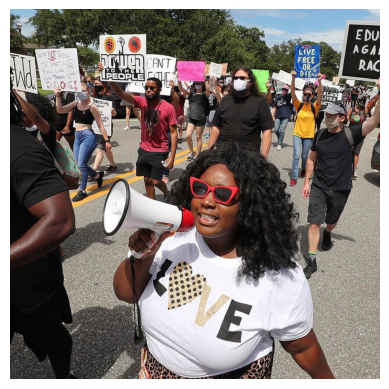

In [30]:
idx = 1
image = os.path.join(image_path, j_data[idx]["image"])
image = Image.open(image).convert("RGB")
plt.imshow(image)
plt.axis("off")

print(*j_data[idx]["caption"], sep="\n")
print(len(j_data[idx]["caption"]))

In [25]:
# Split those with 4 captions as test set, and the rest as train set
test_data = []
train_data = []
for i in range(len(j_data)):
    if len(j_data[i]["caption"]) == 4:
        test_data.append(j_data[i])
    else:
        train_data.append(j_data[i])

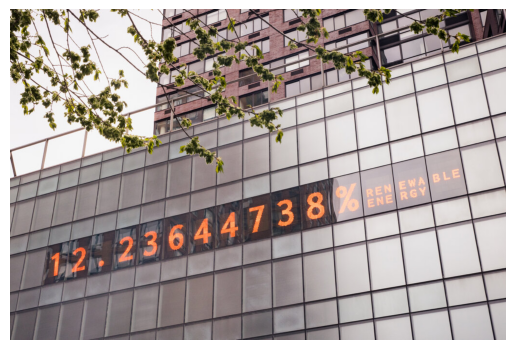

In [27]:
idx = 2
image = os.path.join(image_path, train_data[idx]["image"])
image = Image.open(image).convert("RGB")
plt.imshow(image)
plt.axis("off")

print(*train_data[idx]["caption"], sep="\n")

In [23]:
# Now every image has more than 1 caption, so we need to split them into one caption per image
train_data_single = []
for i in range(len(train_data)):
    for j in range(len(train_data[i]["caption"])):
        tmp_item = train_data[i]
        print(tmp_item)
        tmp_item["caption"] = train_data[i]["caption"][j]
        train_data_single.append(tmp_item)

{'image_id': 0, 'ImgId': '00715db9-9c9e-5d82-a41e-1e23b3a23659_cap2_2', 'image': '00715db9-9c9e-5d82-a41e-1e23b3a23659_cap2_2.png', 'caption': 'a'}
{'image_id': 1, 'ImgId': '0091ac4b-9315-5eaa-9044-9c6a37560b64', 'image': '0091ac4b-9315-5eaa-9044-9c6a37560b64.png', 'caption': 'h'}
{'image_id': 2, 'ImgId': 'd20127d7-3c04-55bf-af37-82ee000bb1ec', 'image': 'd20127d7-3c04-55bf-af37-82ee000bb1ec.png', 'caption': ' '}
{'image_id': 3, 'ImgId': '0186e838-7afe-575a-81fd-87044e3ee50c_cap2_2', 'image': '0186e838-7afe-575a-81fd-87044e3ee50c_cap2_2.png', 'caption': 'T'}
{'image_id': 4, 'ImgId': 'd20127d7-3c04-55bf-af37-82ee000bb1ec_cap2_1', 'image': 'd20127d7-3c04-55bf-af37-82ee000bb1ec_cap2_1.png', 'caption': ['New Yorks Union Square', "New York's Union Square on a bright day with clear clouds. It features a bustling urban scene with tall buildings, a round center where people are passing by, and some trees in the middle. The bustling activity and the presence of tall buildings evoke a sense of ur

IndexError: string index out of range

In [18]:
json.dump(
    train_data,
    open("/project/Impressions/metadata/impressions_train_multiple.json", "w"),
    indent=4,
)

shrapnel from a Hamas rocket
Two law enforcement officials dressed head to toe in protective gear investigate the remains of a Hamas rocket, which has already gone off. In the background, civilians and cops alike stand by, awaiting information and next steps.
I feel sick of seeing images of violence and law enforcement interference. Our country has serious, deep rooted wounds in our culture, and that becomes obvious when images such as these are so commonplace.
The body language of the people in the background is so casual, it reminds me of how commonplace incidents such as this are in the United States. The action in the foreground is also just a familiar image to me, which evokes those feelings of exhaustion at seeing the same violence played out a million different ways.


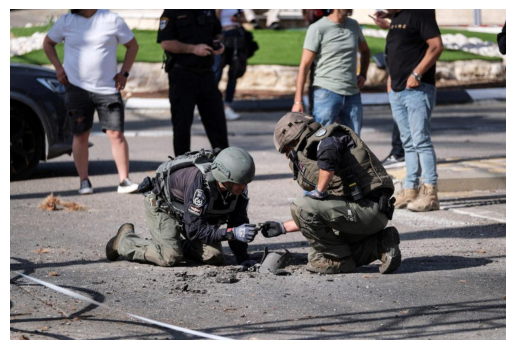

In [12]:
idx = 0
image = os.path.join(image_path, test_data[idx]["image"])
image = Image.open(image).convert("RGB")
plt.imshow(image)
plt.axis("off")

print(*test_data[idx]["caption"], sep="\n")

In [15]:
json.dump(
    test_data,
    open("/project/Impressions/metadata/impressions_test.json", "w"),
    indent=4,
)